## Carbohydrate Metabolism

One of the prevailing health result from obesity is alteration of metabolism. Particularly, glucose or carbohydrate metabolism is affected, resulting in diabetes mellitus. The next set of labs that will be analyzed are blood glucose (fasting), insulin, and hemoglobin A1c.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import math
import scipy.stats as stats
from math import erf, sqrt
from math import atanh, sqrt

In [2]:
df_a = pd.read_csv('cleaned_anthropometry.csv')
df_d = pd.read_csv('cleaned_demographics.csv')
df_i = pd.read_csv('insulin.csv')
df_h = pd.read_csv('hgb_a1c.csv')
df_g = pd.read_csv('fasting_glucose.csv')

In [3]:
df_a.head()

,participant_id,weight_kg,weight_comment,recumbent_length_cm,standing_height,standing_height_comment,bmi,bmi_category_child,upper_leg_cm,upper_arm_cm,arm_circumference_cm,waist_circ_cm,hip_circ_cm
0,109264.0,42.2,NaN,NaN,154.7,NaN,17.6,2.0,36.3,33.8,22.7,63.8,85.0
1,109265.0,12.0,NaN,91.6,89.3,NaN,15.0,2.0,NaN,18.6,14.8,41.2,NaN
2,109266.0,97.1,NaN,NaN,160.2,NaN,37.8,NaN,40.8,34.7,35.8,117.9,126.1
3,109269.0,13.6,NaN,90.9,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,109270.0,75.3,NaN,NaN,156.0,NaN,30.9,4.0,42.6,36.1,31.0,91.4,NaN


In [4]:
df_a.columns

Index(['participant_id', 'weight_kg', 'weight_comment', 'recumbent_length_cm',
       'standing_height', 'standing_height_comment', 'bmi',
       'bmi_category_child', 'upper_leg_cm', 'upper_arm_cm',
       'arm_circumference_cm', 'waist_circ_cm', 'hip_circ_cm'],
      dtype='object')

In [5]:
df_a = df_a.drop(['weight_kg', 'weight_comment', 'recumbent_length_cm',
       'standing_height', 'standing_height_comment','bmi_category_child', 'upper_leg_cm', 'upper_arm_cm',
       'arm_circumference_cm', 'waist_circ_cm', 'hip_circ_cm'], axis=1)

In [6]:
df_a.head()

,participant_id,bmi
0,109264.0,17.6
1,109265.0,15.0
2,109266.0,37.8
3,109269.0,NaN
4,109270.0,30.9


In [7]:
df_a.isna().sum()

participant_id      0
bmi               970
dtype: int64

In [8]:
df_a = df_a.dropna(subset=['bmi'])

In [9]:
df_a.isna().sum()

participant_id    0
bmi               0
dtype: int64

In [10]:
df_d.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty
0,109263.0,1.0,2.0,6.0,NaN,NaN,4.66
1,109264.0,2.0,13.0,1.0,NaN,NaN,0.83
2,109265.0,1.0,2.0,3.0,NaN,NaN,3.06
3,109266.0,2.0,29.0,6.0,5.0,3.0,5.00
4,109269.0,1.0,2.0,2.0,NaN,NaN,0.96


In [11]:
df = df_a.merge(df_d, on = 'participant_id')

In [12]:
df.head()

,participant_id,bmi,gender,age_year,race,education_level,marital_status,family_income_poverty
0,109264.0,17.6,2.0,13.0,1.0,NaN,NaN,0.83
1,109265.0,15.0,1.0,2.0,3.0,NaN,NaN,3.06
2,109266.0,37.8,2.0,29.0,6.0,5.0,3.0,5.00
3,109270.0,30.9,2.0,11.0,4.0,NaN,NaN,1.88
4,109271.0,29.7,1.0,49.0,3.0,2.0,3.0,NaN


In [13]:
df.isna().sum()

participant_id              0
bmi                         0
gender                      0
age_year                    0
race                        0
education_level          4756
marital_status           4756
family_income_poverty    1694
dtype: int64

In [14]:
df = df.drop(['education_level','marital_status','family_income_poverty'], axis=1)

### Fasting Glucose

Fasting glucose is a way to gauge carbohydrate metabolism. The ranges for the fasting glucose levels are as follows:
* Normal: <100 mg/dL
* Prediabetes: 100-125 mg/dL
* Diabetes: >125 mg/dL

In [15]:
df_g.head()

,Unnamed: 0,participant_id,fasting_glucose_mg_dl,fasting_glucose_mmol_l
0,0,109264.0,97.0,5.38
1,1,109271.0,103.0,5.72
2,2,109274.0,154.0,8.55
3,3,109277.0,92.0,5.11
4,4,109282.0,95.0,5.27


In [16]:
df_g = df_g.drop(['Unnamed: 0','fasting_glucose_mmol_l'], axis=1)

In [17]:
df = df.merge(df_g, on='participant_id')

In [18]:
df.head()

,participant_id,bmi,gender,age_year,race,fasting_glucose_mg_dl
0,109264.0,17.6,2.0,13.0,1.0,97.0
1,109271.0,29.7,1.0,49.0,3.0,103.0
2,109274.0,30.2,1.0,68.0,7.0,154.0
3,109277.0,18.6,2.0,12.0,1.0,92.0
4,109282.0,26.6,1.0,76.0,3.0,95.0


In [27]:
df.isna().sum()

participant_id             0
bmi                        0
gender                     0
age_year                   0
race                       0
fasting_glucose_mg_dl    326
dtype: int64

In [28]:
df = df.dropna(subset=['fasting_glucose_mg_dl'])

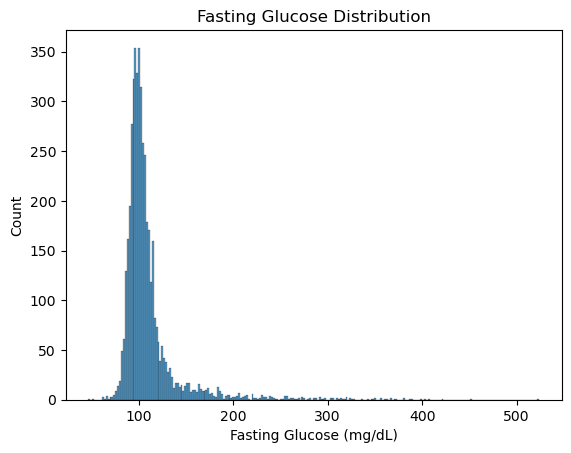

In [29]:
sns.histplot(data=df, x='fasting_glucose_mg_dl')
plt.title('Fasting Glucose Distribution')
plt.xlabel('Fasting Glucose (mg/dL)')
plt.ylabel('Count')
plt.show()

#the histogram looks a little right skewed but it looks fairly normally distributed

In [30]:
df.describe()

,participant_id,bmi,gender,age_year,race,fasting_glucose_mg_dl
count,4659.000000,4659.000000,4659.000000,4659.000000,4659.000000,4659.000000
mean,117145.050440,29.153595,1.514273,45.377978,3.479287,111.044859
std,4476.661666,7.701039,0.499850,20.504413,1.632955,36.131795
min,109264.000000,14.600000,1.000000,12.000000,1.000000,47.000000
25%,113300.500000,23.900000,1.000000,27.000000,3.000000,95.000000
50%,117196.000000,27.900000,2.000000,46.000000,3.000000,102.000000
75%,120990.000000,33.000000,2.000000,62.000000,4.000000,112.000000
max,124822.000000,92.300000,2.000000,80.000000,7.000000,524.000000


In [32]:
df['fasting_glucose_mg_dl'].median()

102.0

In [33]:
df['fasting_glucose_mg_dl'].skew()

4.319883148182733

In [34]:
df['fasting_glucose_mg_dl'].quantile([0.95, 0.99])

0.95    171.00
0.99    291.42
Name: fasting_glucose_mg_dl, dtype: float64

Fasting glucose of over 500 mg/dL is not common but physiologically possible. The decision was made to keep all the data points for data integrity. 

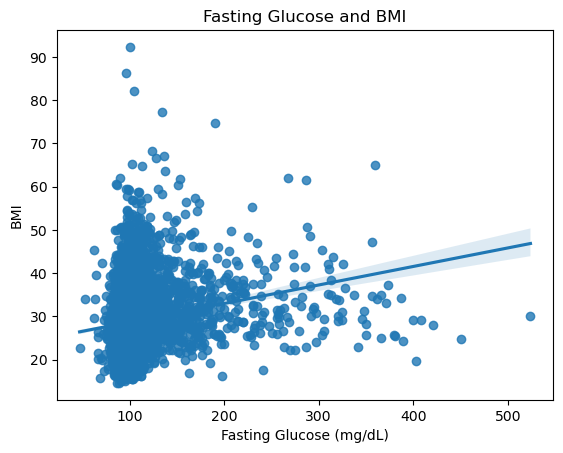

In [36]:
sns.regplot(data=df, x='fasting_glucose_mg_dl',y='bmi')
plt.title("Fasting Glucose and BMI")
plt.xlabel('Fasting Glucose (mg/dL)')
plt.ylabel('BMI')
plt.show()